# Fashion-MNIST Neural Network Implementation

This notebook implements a Neural Network model using PyTorch for the Fashion-MNIST dataset. It includes data loading, model definition, training, evaluation, plotting, saving model weights, and generating a submission file.

## Setup: Importing Libraries

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
import os

## Step 1: Load and Prepare Data

### Data Loading Function

In [2]:
def load_fashion_mnist(batch_size=64):
    # Define transformations for the training and test sets
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,)) # Normalize pixel values to be between -1 and 1
    ])

    # Download and load the training data
    train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    # Download and load the test data
    test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, test_loader

### Load Data and Display a Sample

100%|██████████| 26421880/26421880 [00:04<00:00, 5284492.16it/s]


Extracting ./data\FashionMNIST\raw\train-images-idx3-ubyte.gz to ./data\FashionMNIST\raw



100%|██████████| 29515/29515 [00:00<00:00, 154595.58it/s]


Extracting ./data\FashionMNIST\raw\train-labels-idx1-ubyte.gz to ./data\FashionMNIST\raw



100%|██████████| 4422102/4422102 [00:02<00:00, 1595921.23it/s]


Extracting ./data\FashionMNIST\raw\t10k-images-idx3-ubyte.gz to ./data\FashionMNIST\raw



100%|██████████| 5148/5148 [00:00<?, ?it/s]


Extracting ./data\FashionMNIST\raw\t10k-labels-idx1-ubyte.gz to ./data\FashionMNIST\raw

Shape of images batch: torch.Size([64, 1, 28, 28])
Shape of labels batch: torch.Size([64])


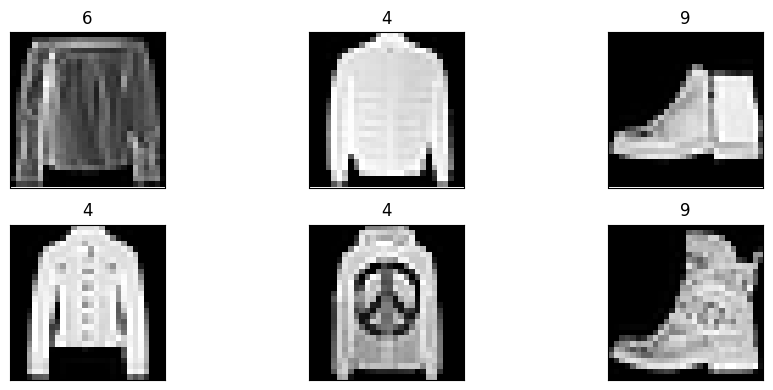

In [3]:
# Load the Fashion-MNIST dataset
train_loader, test_loader = load_fashion_mnist(batch_size=64)

# Get one batch of training images
images, labels = next(iter(train_loader))

print(f"Shape of images batch: {images.shape}")
print(f"Shape of labels batch: {labels.shape}")

# Display a few images from the training set
fig = plt.figure(figsize=(10, 4))
for i in range(6):
    ax = fig.add_subplot(2, 3, i + 1, xticks=[], yticks=[])
    # Undo normalization for display: (img * 0.5) + 0.5
    plt.imshow(images[i].squeeze().numpy() * 0.5 + 0.5, cmap='gray')
    ax.set_title(str(labels[i].item()))
plt.tight_layout()
plt.show()

## Step 2: Define the Neural Network Model

In [4]:
class FashionMNIST_NN(nn.Module):
    def __init__(self):
        super(FashionMNIST_NN, self).__init__()
        self.flatten = nn.Flatten()
        self.network = nn.Sequential(
            nn.Linear(28 * 28, 512),  # Input layer: 28*28 pixels to 512 neurons
            nn.ReLU(),               # Activation function
            nn.Linear(512, 256),     # Hidden layer: 512 to 256 neurons
            nn.ReLU(),
            nn.Linear(256, 10)       # Output layer:(Fashion-MNIST has 10 classes)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.network(x)
        return logits

### Instantiate the Model

In [5]:
# Instantiate the model
model = FashionMNIST_NN()
print(model)

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(f"Using device: {device}")

FashionMNIST_NN(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)
Using device: cpu


## Step 3: Define Loss Function, Optimizer, and Training Loop

### Loss Function and Optimizer

In [6]:
# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

### Training Function

In [7]:
def train_model(model, train_loader, criterion, optimizer, device):
    model.train()  # Set the model to training mode
    running_loss = 0.0
    correct_predictions = 0
    total_predictions = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        # Calculate accuracy
        _, predicted = torch.max(outputs.data, 1)
        total_predictions += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_accuracy = correct_predictions / total_predictions
    return epoch_loss, epoch_accuracy

### Validation Function

In [8]:
def validate_model(model, test_loader, criterion, device):
    model.eval()  # Set the model to evaluation mode
    running_loss = 0.0
    correct_predictions = 0
    total_predictions = 0

    with torch.no_grad():  # Disable gradient calculation during validation
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs.data, 1)
            total_predictions += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(test_loader.dataset)
    epoch_accuracy = correct_predictions / total_predictions
    return epoch_loss, epoch_accuracy

## Step 4: Train the Model and Plot Results

In [9]:
num_epochs = 10
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

print("Starting model training...")

for epoch in range(num_epochs):
    # Train the model
    train_loss, train_accuracy = train_model(model, train_loader, criterion, optimizer, device)
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    # Validate the model
    val_loss, val_accuracy = validate_model(model, test_loader, criterion, device)
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    print(f'Epoch {epoch+1}/{num_epochs}: ')
    print(f'  Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}')
    print(f'  Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}')

print("Training complete.")

Starting model training...
Epoch 1/10: 
  Train Loss: 0.4792, Train Accuracy: 0.8263
  Val Loss: 0.4505, Val Accuracy: 0.8310
Epoch 2/10: 
  Train Loss: 0.3633, Train Accuracy: 0.8666
  Val Loss: 0.3856, Val Accuracy: 0.8590
Epoch 3/10: 
  Train Loss: 0.3242, Train Accuracy: 0.8802
  Val Loss: 0.3479, Val Accuracy: 0.8724
Epoch 4/10: 
  Train Loss: 0.2947, Train Accuracy: 0.8903
  Val Loss: 0.3629, Val Accuracy: 0.8720
Epoch 5/10: 
  Train Loss: 0.2755, Train Accuracy: 0.8954
  Val Loss: 0.3436, Val Accuracy: 0.8803
Epoch 6/10: 
  Train Loss: 0.2592, Train Accuracy: 0.9027
  Val Loss: 0.3321, Val Accuracy: 0.8815
Epoch 7/10: 
  Train Loss: 0.2443, Train Accuracy: 0.9084
  Val Loss: 0.3272, Val Accuracy: 0.8862
Epoch 8/10: 
  Train Loss: 0.2302, Train Accuracy: 0.9133
  Val Loss: 0.3349, Val Accuracy: 0.8827
Epoch 9/10: 
  Train Loss: 0.2164, Train Accuracy: 0.9184
  Val Loss: 0.3607, Val Accuracy: 0.8806
Epoch 10/10: 
  Train Loss: 0.2078, Train Accuracy: 0.9204
  Val Loss: 0.3419, Val

### Plotting Training and Validation Metrics

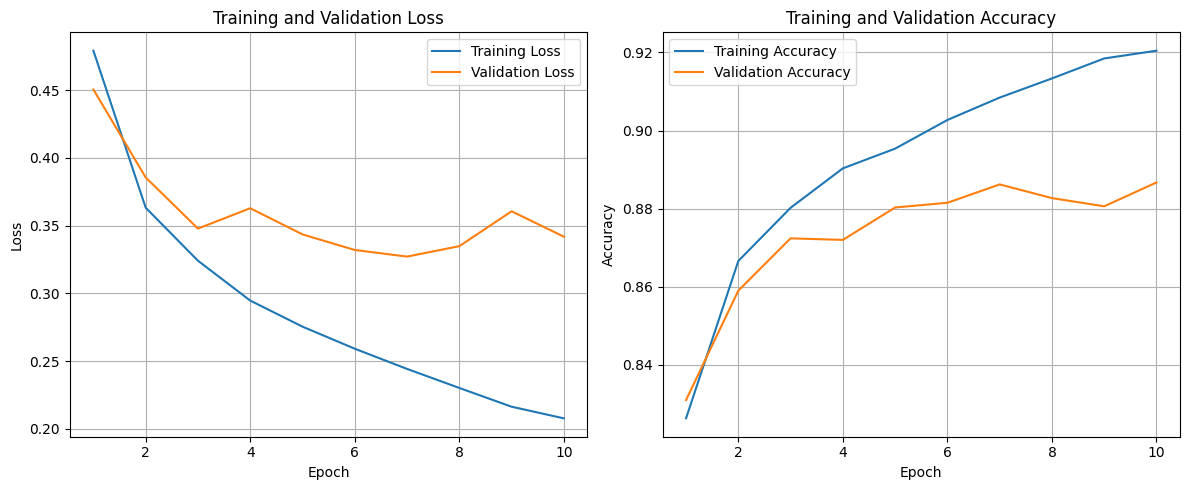

In [10]:
# Plotting the loss and accuracy
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs + 1), train_losses, label='Training Loss')
plt.plot(range(1, num_epochs + 1), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs + 1), train_accuracies, label='Training Accuracy')
plt.plot(range(1, num_epochs + 1), val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Step 5: Save Model Weights

In [11]:
save_dir = os.path.abspath(os.path.join(os.getcwd(), '..', 'saved_models'))
os.makedirs(save_dir, exist_ok=True)
model_filename = os.path.join(save_dir, 'fashion_mnist_nn_model.pkl')
with open(model_filename, 'wb') as f:
    pickle.dump(model.state_dict(), f)
print(f"Model weights saved to {model_filename}")

Model weights saved to c:\Users\sneha\Desktop\spider_ml_task_1\base_task\saved_models\fashion_mnist_nn_model.pkl


## Step 6: Generate a Submission CSV for Test Predictions

### Generate Predictions and Submission File

In [ ]:
def generate_predictions(model, test_loader, device):
    model.eval()  # Set the model to evaluation mode
    predictions = []
    with torch.no_grad():
        for images, _ in test_loader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            predictions.extend(predicted.cpu().numpy())
    return predictions

# Generate predictions for the test set
test_predictions = generate_predictions(model, test_loader, device)

# Create a submission DataFrame
# Here, we'll use a placeholder for image IDs.

submission_df = pd.DataFrame({'ImageId': range(1, len(test_predictions) + 1), 'Label': test_predictions})
base_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
submission_filename = os.path.join(base_dir, 'submission.csv')
submission_df.to_csv(submission_filename, index=False)

print(f"Submission file '{submission_filename}' created successfully with {len(test_predictions)} predictions.")
print(submission_df.head())

Submission file 'c:\Users\sneha\Desktop\spider_ml_task_1\base_task\submission.csv' created successfully with 10000 predictions.
   ImageId  Label
0        1      9
1        2      2
2        3      1
3        4      1
4        5      0
